# ANN Orchestrator For Multi-Run Ensembling and Checkpointing

This notebook defines a reusable orchestrator that:
1. Configures a set of runs (architectures, hyperparameters, number of seeds).
2. Runs expanding-window forecasts and top-k ensembling (same logic as `compute_top_k_ensemble`).
3. Saves model checkpoints at each refit step (DeepSHAP-friendly: torch `state_dict` + preprocessing state).
4. Saves performance tuples per maturity: `(maturity, r2_oos, rsz_pval)`.

The example at the bottom runs a simple forward-only ANN with `n_models=10` and `k_top=1`.

In [ ]:
import os
import sys
from pathlib import Path
from dataclasses import dataclass, asdict
from datetime import datetime
from typing import Callable, Any

import numpy as np
import pandas as pd
import torch
import statsmodels.api as sm
from scipy.stats import t as tstat
from tqdm.auto import tqdm

sys.path.insert(0, os.path.abspath('..'))

import utils.base_utils as bu
import utils.window_utils as wu
from utils.macro_grouping import add_group_level, build_full_group_mapping
from models.ann_vector_validation import PyTorchMLPWrapper

# Data prep
start_date = '1971-08-31'
end_date = '2018-12-31'
maturities = ['24', '36', '48', '60', '84', '120']

yields = bu.get_yields(type='lw', start=start_date, end=end_date, maturities=[str(i) for i in range(12, 121) if i % 12 == 0])
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna()
fred_md_raw = bu.get_fred_data('data/2026-01-MD.csv', start=start_date, end=end_date)

fred_md = fred_md_raw.shift(1).bfill()
yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]

s2g = build_full_group_mapping(fred_md, forward, yields)
X = pd.concat([fred_md, forward, yields], axis=1, keys=['fred', 'forward', 'yields'])
X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')

y_all = xr[maturities].values
dates = xr.index

In [2]:
def compute_top_k_ensemble(forecasts_array: np.ndarray, val_losses_array: np.ndarray, k: int):
    # Same ensembling logic as existing notebook code: top-k per maturity and date by val loss.
    T, n_seeds, n_outputs = forecasts_array.shape
    ensemble_forecast = np.full((T, n_outputs), np.nan)
    topk_indices = np.full((T, n_outputs, min(k, n_seeds)), -1, dtype=int)

    for t in range(T):
        for m in range(n_outputs):
            v_losses = val_losses_array[t, :, m]
            valid_idx = np.where(~np.isnan(v_losses))[0]
            if len(valid_idx) == 0:
                continue

            actual_k = min(k, len(valid_idx))
            sorted_valid_idx = valid_idx[np.argsort(v_losses[valid_idx])]
            selected = sorted_valid_idx[:actual_k]

            topk_indices[t, m, :actual_k] = selected
            ensemble_forecast[t, m] = np.mean(forecasts_array[t, selected, m], axis=0)

    return ensemble_forecast, topk_indices


def _extract_scaler_state(scaler: Any):
    if scaler is None:
        return None
    state = {}
    for attr in ['mean_', 'scale_', 'var_', 'n_samples_seen_', 'n_features_in_']:
        if hasattr(scaler, attr):
            val = getattr(scaler, attr)
            if isinstance(val, np.ndarray):
                state[attr] = val.copy()
            elif np.isscalar(val):
                state[attr] = val.item() if hasattr(val, 'item') else val
            else:
                state[attr] = val
    return state


def _extract_pca_state(pca: Any):
    if pca is None:
        return None
    state = {}
    for attr in ['components_', 'mean_', 'explained_variance_', 'explained_variance_ratio_', 'n_components_']:
        if hasattr(pca, attr):
            val = getattr(pca, attr)
            state[attr] = val.copy() if isinstance(val, np.ndarray) else val
    return state


def _estimate_model_size_mb(wrapper_model: torch.nn.Module) -> float:
    n_params = sum(p.numel() for p in wrapper_model.parameters())
    return (n_params * 4) / (1024 ** 2)

In [ ]:
@dataclass
class RunConfig:
    run_name: str
    model_builder: Callable[[int], Any]
    n_models: int
    k_top: int
    maturities: list
    oos_start: pd.Timestamp
    gap: int = 0
    refit_freq: int = 1
    benchmark: str = 'hist_mean'
    rsz_maxlags: int = 12
    progress: bool = False
    artifacts_root: Path = Path('../artifacts/orchestrator_runs')


def _save_checkpoint(wrapper, seed: int, t_index: int, date_value, run_dir: Path) -> Path:
    ckpt_dir = run_dir / 'checkpoints' / f'seed_{seed:03d}'
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / f'step_{t_index:04d}_{pd.Timestamp(date_value).date()}.pt'

    x_scalers_macro_state = None
    if hasattr(wrapper, 'x_scalers_macro') and isinstance(wrapper.x_scalers_macro, dict):
        x_scalers_macro_state = {k: _extract_scaler_state(v) for k, v in wrapper.x_scalers_macro.items()}

    checkpoint = {
        'wrapper_class': wrapper.__class__.__name__,
        'wrapper_module': wrapper.__class__.__module__,
        'torch_state_dict': wrapper.model.state_dict() if hasattr(wrapper, 'model') and wrapper.model is not None else None,
        'best_params_': getattr(wrapper, 'best_params_', None),
        'fit_calls': getattr(wrapper, '_fit_calls', None),
        'x_scaler': _extract_scaler_state(getattr(wrapper, 'x_scaler', None)),
        'x_scaler_forward': _extract_scaler_state(getattr(wrapper, 'x_scaler_forward', None)),
        'x_scaler_fred': _extract_scaler_state(getattr(wrapper, 'x_scaler_fred', None)),
        'x_scalers_macro': x_scalers_macro_state,
        'y_scaler': _extract_scaler_state(getattr(wrapper, 'y_scaler', None)),
        'pca': _extract_pca_state(getattr(wrapper, 'pca', None)),
    }

    torch.save(checkpoint, ckpt_path)
    return ckpt_path


def run_experiment(cfg: RunConfig, X: pd.DataFrame, y_all: np.ndarray, dates: pd.DatetimeIndex):
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    run_dir = (cfg.artifacts_root / cfg.run_name / ts).resolve()
    run_dir.mkdir(parents=True, exist_ok=True)

    T = len(dates)
    n_outputs = y_all.shape[1] if y_all.ndim > 1 else 1

    all_forecasts = []
    all_val_losses = []
    ckpt_manifest = []

    model_iter = range(cfg.n_models)
    if cfg.progress:
        model_iter = tqdm(model_iter, desc='Seeds')

    for seed in model_iter:
        model = cfg.model_builder(seed)
        val_losses_for_seed = np.full((T, n_outputs), np.nan)

        # This callback is triggered at each refit step by expanding_window.
        def save_cb(model, refit_i, t_index, date_value, **kwargs):
            if hasattr(model, 'val_loss_') and model.val_loss_ is not None:
                val_losses_for_seed[t_index] = model.val_loss_

            ckpt_path = _save_checkpoint(model, seed, t_index, date_value, run_dir)
            ckpt_manifest.append({
                'seed': seed,
                'refit_i': refit_i,
                't_index': int(t_index),
                'date': str(pd.Timestamp(date_value).date()),
                'checkpoint_path': str(ckpt_path),
            })

        y_forecast = wu.expanding_window(
            model, X, y_all, dates, cfg.oos_start,
            gap=cfg.gap,
            refit_freq=cfg.refit_freq,
            save_callback=save_cb,
            progress=False,
        )

        all_forecasts.append(y_forecast)
        all_val_losses.append(val_losses_for_seed)

    forecasts_arr = np.stack(all_forecasts, axis=1)
    losses_arr = np.stack(all_val_losses, axis=1)

    ensemble_forecast, topk_indices = compute_top_k_ensemble(forecasts_arr, losses_arr, cfg.k_top)

    r2s = wu.oos_r2(y_all, ensemble_forecast, benchmark=cfg.benchmark)
    pvals = np.array([bu.RSZ_Signif(y_all[:, i], ensemble_forecast[:, i])
                     for i in range(n_outputs)])

    performance_tuples = list(zip(cfg.maturities, r2s.tolist(), pvals.tolist()))

    # Persist arrays and metadata
    np.save(run_dir / 'forecasts_arr.npy', forecasts_arr)
    np.save(run_dir / 'losses_arr.npy', losses_arr)
    np.save(run_dir / 'ensemble_forecast.npy', ensemble_forecast)
    np.save(run_dir / 'topk_indices.npy', topk_indices)

    pd.DataFrame(ckpt_manifest).to_csv(run_dir / 'checkpoint_manifest.csv', index=False)
    perf_df = pd.DataFrame(performance_tuples, columns=['maturity', 'r2_oos', 'rsz_pval'])
    perf_df.to_csv(run_dir / 'performance.csv', index=False)

    serializable_cfg = asdict(cfg)
    serializable_cfg['model_builder'] = str(cfg.model_builder)
    serializable_cfg['artifacts_root'] = str(cfg.artifacts_root)
    pd.Series(serializable_cfg).to_json(run_dir / 'run_config.json', indent=2)

    # Storage summary
    ckpt_paths = list((run_dir / 'checkpoints').rglob('*.pt'))
    total_ckpt_bytes = sum(p.stat().st_size for p in ckpt_paths)

    summary = {
        'run_dir': str(run_dir),
        'num_checkpoints': len(ckpt_paths),
        'total_checkpoint_gb': total_ckpt_bytes / (1024 ** 3),
        'performance': performance_tuples,
        'forecasts_arr_shape': forecasts_arr.shape,
        'losses_arr_shape': losses_arr.shape,
    }

    return summary

Main block for running:

In [ ]:
nodes = [3, 5, 7]
architectures = [(h,) for h in nodes] + [(h, h) for h in nodes]

def arch_to_name(arch):
    return "&".join(str(x) for x in arch)

def make_fwd_ann_cfg(arch, n_models=100, k_top=10):
    return RunConfig(
        run_name=f"fwd_ann_{arch_to_name(arch)}_{n_models}runs_top{k_top}",
        model_builder=lambda seed, arch=arch: PyTorchMLPWrapper(
        archi=arch,
        lr=0.01,
        epochs=1000,
        tune_every=60,
        patience=50,
        param_grid={"penalty": [0.01, 0.001, 0.0001]},
        seed=seed,
        use_pca=False,
        n_components=None,
        y_center=False,
        ),
        n_models=n_models,
        k_top=k_top,
        maturities=maturities,
        oos_start=pd.Timestamp("1990-01-31"),
        gap=0,
        refit_freq=1,
        benchmark="hist_mean",
        progress=True,
        )

run_configs = [make_fwd_ann_cfg(arch) for arch in architectures]

all_summaries = []
for cfg in run_configs:
    print(f"Running {cfg.run_name} ...")
all_summaries.append(run_experiment(cfg, X, y_all, dates))

## Companion: Reload One Checkpoint and Compute SHAP

This section verifies end-to-end compatibility by:
1. Loading one saved checkpoint from the orchestrator artifacts.
2. Reconstructing the forward-only ANN torch model from checkpoint weights.
3. Reapplying saved preprocessing (scaler and optional PCA).
4. Computing SHAP values for one chosen maturity and date.

Notes:
- This companion cell currently targets `PyTorchMLPWrapper` checkpoints.

Run dir: ../artifacts/orchestrator_runs/fwd_ann_pcc_4runs_top2/20260320_142422
Checkpoint: /home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/fwd_ann_pcc_4runs_top2/20260320_142422/checkpoints/seed_000/step_0497_2013-01-31.pt
Chosen date: 2013-01-31
Chosen maturity: 120
Chosen seed: 0
Inferred architecture: (3,)
Input feature space for SHAP: PCA components


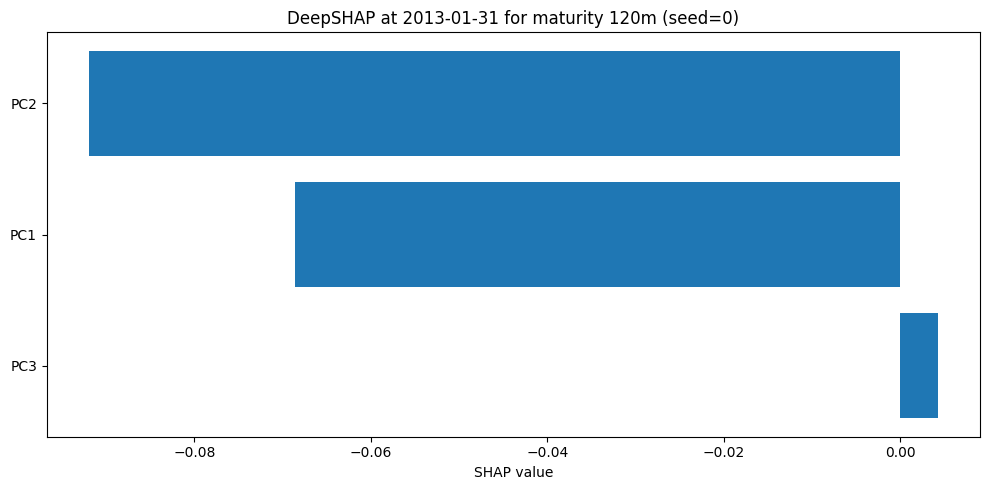

,feature,shap,abs_shap
1,PC2,-0.091927,0.091927
0,PC1,-0.068636,0.068636
2,PC3,0.004254,0.004254


In [22]:
import importlib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import shap

# ---------- Artifact selection ----------
# Preferred workflow: point to run_name (+ optional timestamp) and load checkpoints without rerunning training.
artifacts_root = Path('../artifacts/orchestrator_runs')
run_name = 'fwd_ann_pcc_4runs_top2'
run_timestamp = None  # None -> use latest timestamp folder under artifacts_root/run_name
# ---------------------------------------

# ---------- User selections ----------
chosen_maturity = '120'   # maturity (in months) to explain
chosen_seed_rank = 1      # rank within top-k seeds at chosen date: 0=best, 1=second-best, ...
chosen_date = '2013-01-31'  # OOS date to explain; use None to pick latest valid date
background_size = 128     # number of historical rows used as DeepSHAP background distribution
# ------------------------------------


def resolve_run_dir(base_dir: Path, run_name: str, run_timestamp: str | None = None) -> Path:
    run_root = base_dir / run_name
    if not run_root.exists():
        raise FileNotFoundError(f"Run root does not exist: {run_root}")

    if run_timestamp is not None:
        run_dir = run_root / run_timestamp
        if not run_dir.exists():
            raise FileNotFoundError(f"Requested run timestamp not found: {run_dir}")
        return run_dir

    candidates = sorted([p for p in run_root.iterdir() if p.is_dir()])
    if not candidates:
        raise FileNotFoundError(f"No timestamped runs found under: {run_root}")
    return candidates[-1]


# Load run artifacts produced by run_experiment(...)
run_dir = resolve_run_dir(artifacts_root, run_name, run_timestamp)
manifest = pd.read_csv(run_dir / 'checkpoint_manifest.csv')
topk_indices = np.load(run_dir / 'topk_indices.npy')

if chosen_maturity not in maturities:
    raise ValueError(f"chosen_maturity={chosen_maturity} not found in maturities list")

# Map maturity label -> output index in multi-output network
m_idx = maturities.index(chosen_maturity)

# Resolve which time index to explain.
# If date is None, we use the latest OOS date with a valid top-k model for this maturity.
if chosen_date is None:
    valid_t = np.where(topk_indices[:, m_idx, 0] >= 0)[0]
    if len(valid_t) == 0:
        raise RuntimeError("No valid top-k selection found for the chosen maturity.")
    t_idx = int(valid_t[-1])
else:
    matches = np.where(pd.to_datetime(dates) == pd.Timestamp(chosen_date))[0]
    if len(matches) == 0:
        raise ValueError(f"chosen_date={chosen_date} not found in `dates`.")
    t_idx = int(matches[0])

# IMPORTANT: We are loading ONE selected model checkpoint, not all top-k models.
# chosen_seed_rank=0 means the best-ranked seed for this maturity/date.
seed = int(topk_indices[t_idx, m_idx, chosen_seed_rank])
if seed < 0:
    raise RuntimeError("Selected top-k slot has no seed (value -1).")

# Locate the exact checkpoint file for that seed and date index.
row = manifest[(manifest['seed'] == seed) & (manifest['t_index'] == t_idx)]
if row.empty:
    raise RuntimeError(f"No checkpoint found for seed={seed}, t_index={t_idx}")
ckpt_path = Path(row.iloc[0]['checkpoint_path'])

# Load checkpoint payload (weights + preprocessing states + metadata).
checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
if checkpoint.get('wrapper_class') != 'PyTorchMLPWrapper':
    raise NotImplementedError("Companion SHAP cell currently supports PyTorchMLPWrapper checkpoints.")

# Rebuild the torch network architecture from saved linear layer weight shapes.
state_dict = checkpoint['torch_state_dict']
linear_keys = [k for k, v in state_dict.items() if k.endswith('.weight') and getattr(v, 'ndim', 0) == 2]
linear_keys = sorted(linear_keys, key=lambda k: int(k.split('.')[1]))

if len(linear_keys) < 2:
    raise RuntimeError("Unexpected state_dict format; could not infer network architecture.")

in_dim = int(state_dict[linear_keys[0]].shape[1])
out_dim = int(state_dict[linear_keys[-1]].shape[0])
hidden_arch = tuple(int(state_dict[k].shape[0]) for k in linear_keys[:-1])

ann_mod = importlib.import_module('models.ann_vector_validation')
NetworkCls = getattr(ann_mod, '_MLPNetwork')
model = NetworkCls(input_dim=in_dim, archi=hidden_arch, output_dim=out_dim)
model.load_state_dict(state_dict)
model.eval()

# Replay the exact feature preprocessing used at training for this checkpoint.
# This transforms raw forward-rate features into the same model input space.
def apply_saved_preprocessing(X_raw, scaler_state, pca_state):
    Xp = np.asarray(X_raw, dtype=np.float32).copy()

    if scaler_state is not None:
        mean = scaler_state.get('mean_', None)
        scale = scaler_state.get('scale_', None)

        if mean is not None:
            Xp = Xp - np.asarray(mean, dtype=np.float32)

        if scale is not None:
            scale = np.asarray(scale, dtype=np.float32)
            scale = np.where(scale == 0.0, 1.0, scale)
            Xp = Xp / scale

    if pca_state is not None and pca_state.get('components_', None) is not None:
        pca_mean = pca_state.get('mean_', None)
        if pca_mean is not None:
            Xp = Xp - np.asarray(pca_mean, dtype=np.float32)
        comps = np.asarray(pca_state['components_'], dtype=np.float32)
        Xp = Xp @ comps.T

    return Xp

X_forward = X['forward'].values
X_proc = apply_saved_preprocessing(X_forward, checkpoint.get('x_scaler', None), checkpoint.get('pca', None))

# Build DeepSHAP background from historical rows available at that OOS step.
# We explain one row only: X_proc[t_idx].
train_end = max(1, t_idx)
bg_start = max(0, train_end - background_size)
X_bg = X_proc[bg_start:train_end]
X_eval = X_proc[t_idx:t_idx + 1]

if X_bg.shape[0] < 2:
    raise RuntimeError("Not enough background rows for SHAP. Choose a later date or increase sample size.")

bg_tensor = torch.tensor(X_bg, dtype=torch.float32)
eval_tensor = torch.tensor(X_eval, dtype=torch.float32)

# DeepSHAP explains output relative to the background expectation.
explainer = shap.DeepExplainer(model, bg_tensor)
shap_values = explainer.shap_values(eval_tensor)

# Multi-output handling: extract SHAP vector for chosen maturity output.
if isinstance(shap_values, list):
    sv = np.asarray(shap_values[m_idx])[0]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # Expected shape: (n_samples, n_features, n_outputs)
    sv = shap_values[0, :, m_idx]
else:
    sv = np.asarray(shap_values)[0]

sv = np.asarray(sv, dtype=float).reshape(-1)

# Build feature names that match SHAP dimensionality.
raw_feature_names = [col if isinstance(col, str) else ' | '.join(map(str, col)) for col in X['forward'].columns]
if len(raw_feature_names) == len(sv):
    feature_names = raw_feature_names
elif checkpoint.get('pca') is not None and checkpoint['pca'].get('components_') is not None:
    n_pcs = int(np.asarray(checkpoint['pca']['components_']).shape[0])
    if n_pcs == len(sv):
        feature_names = [f'PC{i+1}' for i in range(n_pcs)]
    else:
        feature_names = [f'feature_{i+1}' for i in range(len(sv))]
else:
    feature_names = [f'feature_{i+1}' for i in range(len(sv))]

plot_df = pd.DataFrame({'feature': feature_names, 'shap': sv, 'abs_shap': np.abs(sv)})
plot_df = plot_df.sort_values('abs_shap', ascending=False).head(15)

print('Run dir:', run_dir)
print('Checkpoint:', ckpt_path)
print('Chosen date:', pd.Timestamp(dates[t_idx]).date())
print('Chosen maturity:', chosen_maturity)
print('Chosen seed:', seed)
print('Inferred architecture:', hidden_arch)
print('Input feature space for SHAP:', 'PCA components' if len(feature_names) != len(raw_feature_names) else 'Raw forward features')

# Plot top absolute SHAP features for the selected output at the selected date.
plt.figure(figsize=(10, 5))
plt.barh(plot_df['feature'].iloc[::-1], plot_df['shap'].iloc[::-1])
plt.title(f"DeepSHAP at {pd.Timestamp(dates[t_idx]).date()} for maturity {chosen_maturity}m (seed={seed})")
plt.xlabel('SHAP value')
plt.tight_layout()
plt.show()

plot_df

## Companion 2: Aggregate SHAP Across Top-k Seeds

This companion computes SHAP for all seeds selected in top-k at the chosen date/maturity and aggregates them for an ensemble-consistent explanation.

Aggregation outputs:
1. Unweighted mean SHAP across top-k seeds.
2. Inverse-validation-loss weighted mean SHAP (optional, more weight to better seeds).

Run dir: ../artifacts/orchestrator_runs/fwd_ann_pcc_4runs_top2/20260320_142422
Aggregation date: 2013-01-31
Aggregation maturity: 120
Selected seeds: [3, 0]
Effective seeds used: 2
Input feature space for SHAP: PCA components


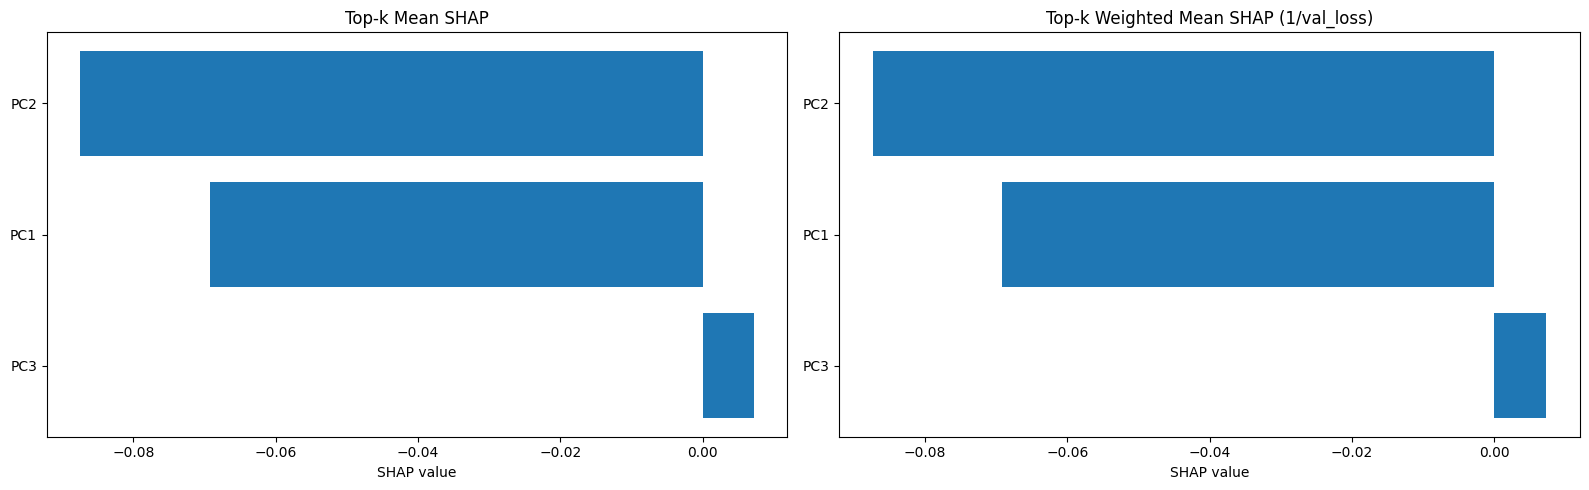

(  feature      shap  abs_shap
 1     PC2 -0.087433  0.087433
 0     PC1 -0.069224  0.069224
 2     PC3  0.007205  0.007205,
   feature      shap  abs_shap
 1     PC2 -0.087317  0.087317
 0     PC1 -0.069239  0.069239
 2     PC3  0.007281  0.007281)

In [24]:
import importlib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import shap

# ---------- Artifact selection ----------
artifacts_root = Path('../artifacts/orchestrator_runs')
run_name = 'fwd_ann_pcc_4runs_top2'
run_timestamp = None  # None -> use latest run for this run_name
# ---------------------------------------

# ---------- User selections ----------
agg_maturity = chosen_maturity if 'chosen_maturity' in globals() else '120'
agg_date = chosen_date if 'chosen_date' in globals() else None
agg_background_size = background_size if 'background_size' in globals() else 128
use_inverse_loss_weights = True
# ------------------------------------


def resolve_run_dir(base_dir: Path, run_name: str, run_timestamp: str | None = None) -> Path:
    run_root = base_dir / run_name
    if not run_root.exists():
        raise FileNotFoundError(f"Run root does not exist: {run_root}")

    if run_timestamp is not None:
        run_dir = run_root / run_timestamp
        if not run_dir.exists():
            raise FileNotFoundError(f"Requested run timestamp not found: {run_dir}")
        return run_dir

    candidates = sorted([p for p in run_root.iterdir() if p.is_dir()])
    if not candidates:
        raise FileNotFoundError(f"No timestamped runs found under: {run_root}")
    return candidates[-1]


run_dir = resolve_run_dir(artifacts_root, run_name, run_timestamp)
manifest = pd.read_csv(run_dir / 'checkpoint_manifest.csv')
topk_indices = np.load(run_dir / 'topk_indices.npy')
losses_arr_disk = np.load(run_dir / 'losses_arr.npy')

if agg_maturity not in maturities:
    raise ValueError(f"agg_maturity={agg_maturity} not found in maturities list")

m_idx = maturities.index(agg_maturity)

# Resolve date index for aggregation.
if agg_date is None:
    valid_t = np.where(topk_indices[:, m_idx, 0] >= 0)[0]
    if len(valid_t) == 0:
        raise RuntimeError("No valid top-k selection found for this maturity.")
    t_idx = int(valid_t[-1])
else:
    matches = np.where(pd.to_datetime(dates) == pd.Timestamp(agg_date))[0]
    if len(matches) == 0:
        raise ValueError(f"agg_date={agg_date} not found in `dates`.")
    t_idx = int(matches[0])

seed_candidates = topk_indices[t_idx, m_idx, :]
selected_seeds = [int(s) for s in seed_candidates if int(s) >= 0]

if len(selected_seeds) == 0:
    raise RuntimeError("No valid seeds in top-k for selected maturity/date.")


def _apply_saved_preprocessing_local(X_raw, scaler_state, pca_state):
    Xp = np.asarray(X_raw, dtype=np.float32).copy()

    if scaler_state is not None:
        mean = scaler_state.get('mean_', None)
        scale = scaler_state.get('scale_', None)

        if mean is not None:
            Xp = Xp - np.asarray(mean, dtype=np.float32)

        if scale is not None:
            scale = np.asarray(scale, dtype=np.float32)
            scale = np.where(scale == 0.0, 1.0, scale)
            Xp = Xp / scale

    if pca_state is not None and pca_state.get('components_', None) is not None:
        pca_mean = pca_state.get('mean_', None)
        if pca_mean is not None:
            Xp = Xp - np.asarray(pca_mean, dtype=np.float32)
        comps = np.asarray(pca_state['components_'], dtype=np.float32)
        Xp = Xp @ comps.T

    return Xp


seed_shap_rows = []
seed_losses = []

for seed in selected_seeds:
    row = manifest[(manifest['seed'] == seed) & (manifest['t_index'] == t_idx)]
    if row.empty:
        continue

    ckpt_path = Path(row.iloc[0]['checkpoint_path'])
    checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    if checkpoint.get('wrapper_class') != 'PyTorchMLPWrapper':
        continue

    # Reconstruct network from stored weights.
    state_dict = checkpoint['torch_state_dict']
    linear_keys = [k for k, v in state_dict.items() if k.endswith('.weight') and getattr(v, 'ndim', 0) == 2]
    linear_keys = sorted(linear_keys, key=lambda k: int(k.split('.')[1]))
    if len(linear_keys) < 2:
        continue

    in_dim = int(state_dict[linear_keys[0]].shape[1])
    out_dim = int(state_dict[linear_keys[-1]].shape[0])
    hidden_arch = tuple(int(state_dict[k].shape[0]) for k in linear_keys[:-1])

    ann_mod = importlib.import_module('models.ann_vector_validation')
    NetworkCls = getattr(ann_mod, '_MLPNetwork')
    model = NetworkCls(input_dim=in_dim, archi=hidden_arch, output_dim=out_dim)
    model.load_state_dict(state_dict)
    model.eval()

    # Replay per-seed preprocessing and explain the single selected row.
    X_forward = X['forward'].values
    X_proc = _apply_saved_preprocessing_local(X_forward, checkpoint.get('x_scaler', None), checkpoint.get('pca', None))

    train_end = max(1, t_idx)
    bg_start = max(0, train_end - agg_background_size)
    X_bg = X_proc[bg_start:train_end]
    X_eval = X_proc[t_idx:t_idx + 1]

    if X_bg.shape[0] < 2:
        continue

    bg_tensor = torch.tensor(X_bg, dtype=torch.float32)
    eval_tensor = torch.tensor(X_eval, dtype=torch.float32)

    explainer = shap.DeepExplainer(model, bg_tensor)
    shap_values = explainer.shap_values(eval_tensor)

    # Pull SHAP vector for the chosen maturity/output node.
    if isinstance(shap_values, list):
        sv = np.asarray(shap_values[m_idx])[0]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        sv = shap_values[0, :, m_idx]
    else:
        sv = np.asarray(shap_values)[0]

    sv = np.asarray(sv, dtype=float).reshape(-1)
    seed_shap_rows.append(sv)

    # Validation loss at this date/seed/maturity, used for optional weighting.
    vloss = losses_arr_disk[t_idx, seed, m_idx]
    seed_losses.append(float(vloss) if np.isfinite(vloss) else np.nan)

if len(seed_shap_rows) == 0:
    raise RuntimeError("No seed SHAP vectors were computed for the selected setup.")

seed_shap_mat = np.vstack(seed_shap_rows)  # shape: (k_effective, n_features)

# Build feature names that match SHAP dimensionality.
raw_feature_names = [col if isinstance(col, str) else ' | '.join(map(str, col)) for col in X['forward'].columns]
if len(raw_feature_names) == seed_shap_mat.shape[1]:
    feature_names = raw_feature_names
else:
    feature_names = [f'PC{i+1}' for i in range(seed_shap_mat.shape[1])]

# Unweighted mean SHAP across top-k seeds.
mean_sv = np.nanmean(seed_shap_mat, axis=0)

# Optional weighted mean: weights proportional to 1 / validation_loss.
losses = np.asarray(seed_losses, dtype=float)
if use_inverse_loss_weights and np.isfinite(losses).any() and np.all(losses[np.isfinite(losses)] > 0):
    w = np.zeros_like(losses)
    good = np.isfinite(losses) & (losses > 0)
    w[good] = 1.0 / losses[good]
    if w.sum() > 0:
        w = w / w.sum()
        weighted_sv = np.nansum(seed_shap_mat * w[:, None], axis=0)
    else:
        weighted_sv = mean_sv.copy()
else:
    weighted_sv = mean_sv.copy()

mean_df = pd.DataFrame({'feature': feature_names, 'shap': mean_sv, 'abs_shap': np.abs(mean_sv)})
mean_df = mean_df.sort_values('abs_shap', ascending=False).head(15)

weighted_df = pd.DataFrame({'feature': feature_names, 'shap': weighted_sv, 'abs_shap': np.abs(weighted_sv)})
weighted_df = weighted_df.sort_values('abs_shap', ascending=False).head(15)

print('Run dir:', run_dir)
print('Aggregation date:', pd.Timestamp(dates[t_idx]).date())
print('Aggregation maturity:', agg_maturity)
print('Selected seeds:', selected_seeds)
print('Effective seeds used:', seed_shap_mat.shape[0])
print('Input feature space for SHAP:', 'PCA components' if len(feature_names) != len(raw_feature_names) else 'Raw forward features')

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=False)
axes[0].barh(mean_df['feature'].iloc[::-1], mean_df['shap'].iloc[::-1])
axes[0].set_title('Top-k Mean SHAP')
axes[0].set_xlabel('SHAP value')

axes[1].barh(weighted_df['feature'].iloc[::-1], weighted_df['shap'].iloc[::-1])
axes[1].set_title('Top-k Weighted Mean SHAP (1/val_loss)')
axes[1].set_xlabel('SHAP value')

plt.tight_layout()
plt.show()

mean_df, weighted_df